**Proyecto: Diagnosico fitosanitario para cultivos de tomate**

# Pre-Procesamiento de datos

## Instalaciones

In [2]:
!pip install kagglehub scikit-image --quiet

## Importaciones

In [3]:

import os
import random
import warnings
import numpy as np
import pandas as pd
import cv2
from scipy.stats import skew
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
import kagglehub

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

## DESCARGA DEL DATASET

In [4]:
ruta_dataset = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print("Path to dataset files:", ruta_dataset)

ruta_segmentadas = os.path.join(ruta_dataset, "plantvillage dataset", "segmented")
print("Ruta de imágenes segmentadas:", ruta_segmentadas)



Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset
Ruta de imágenes segmentadas: /kaggle/input/plantvillage-dataset/plantvillage dataset/segmented


## DEFINICIÓN DE CLASES (subconjunto de 4)

In [5]:
CLASES_OBJETIVO = [
    "Tomato___Early_blight",
    "Tomato___Bacterial_spot",
    "Tomato___healthy",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
]

# Verificación rápida de disponibilidad y conteo por clase
print("\nConteo original por clase:")
conteo_por_clase = {}
for clase in CLASES_OBJETIVO:
    ruta_clase = os.path.join(ruta_segmentadas, clase)
    imagenes   = [f for f in os.listdir(ruta_clase)
                  if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    conteo_por_clase[clase] = imagenes
    print(f"  {clase:<55} {len(imagenes):>5} imágenes")




Conteo original por clase:
  Tomato___Early_blight                                    1000 imágenes
  Tomato___Bacterial_spot                                  2127 imágenes
  Tomato___healthy                                         1591 imágenes
  Tomato___Tomato_Yellow_Leaf_Curl_Virus                   5357 imágenes


In [6]:
# ── 4. BALANCEO POR DOWNSAMPLING ─────────────────────────────────────────────
n_minoritaria = min(len(v) for v in conteo_por_clase.values())
print(f"\nClase minoritaria: {n_minoritaria} imágenes → todas las clases se reducen a este valor.")

imagenes_balanceadas = {}   # {clase: [lista_de_rutas]}
for clase, archivos in conteo_por_clase.items():
    muestra = random.sample(archivos, n_minoritaria)
    imagenes_balanceadas[clase] = [
        os.path.join(ruta_segmentadas, clase, f) for f in muestra
    ]

total_imagenes = sum(len(v) for v in imagenes_balanceadas.values())
print(f"Total imágenes balanceadas: {total_imagenes}  ({n_minoritaria} × {len(CLASES_OBJETIVO)} clases)\n")



Clase minoritaria: 1000 imágenes → todas las clases se reducen a este valor.
Total imágenes balanceadas: 4000  (1000 × 4 clases)



# Procesamiento de datos

 ## EXTRACCIÓN DE CARACTERÍSTICAS

In [7]:
DISTANCIAS_GLCM = [1]
ANGULOS_GLCM    = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]

def crear_mascara(img_bgr: np.ndarray) -> np.ndarray:
    """
    Devuelve una máscara booleana que excluye el fondo negro de las
    imágenes segmentadas de PlantVillage.
    Un píxel es fondo si todos sus canales BGR son ≤ 15.
    """
    return ~(
        (img_bgr[:, :, 0] <= 15) &
        (img_bgr[:, :, 1] <= 15) &
        (img_bgr[:, :, 2] <= 15)
    )

def extraer_caracteristicas(ruta_imagen: str) -> dict | None:
    """
    Calcula el vector de características completo para una imagen.
    Retorna None si la imagen no puede leerse o si la máscara está vacía.
    """
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        return None

    mascara = crear_mascara(img_bgr)
    if mascara.sum() == 0:
        return None

    feats = {}

    # ── 5.1 Características RGB ───────────────────────────────────────────────
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    nombres_rgb = ["R", "G", "B"]
    for idx, canal in enumerate(nombres_rgb):
        valores = img_rgb[:, :, idx][mascara].astype(np.float32)
        feats[f"mean_{canal}"] = float(np.mean(valores))
        feats[f"std_{canal}"]  = float(np.std(valores))
        feats[f"var_{canal}"]  = float(np.var(valores))
        feats[f"skew_{canal}"] = float(skew(valores))

    # ── 5.2 Características HSV ───────────────────────────────────────────────
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    nombres_hsv = ["H", "S", "V"]
    for idx, canal in enumerate(nombres_hsv):
        valores = img_hsv[:, :, idx][mascara].astype(np.float32)
        feats[f"mean_{canal}"] = float(np.mean(valores))
        feats[f"std_{canal}"]  = float(np.std(valores))

    # ── 5.3 Características LAB (CIELAB) ─────────────────────────────────────
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    nombres_lab = ["L", "A", "B_lab"]   # B_lab para no colisionar con B de RGB
    canales_lab = ["L", "A", "B"]
    for idx, (nombre, canal) in enumerate(zip(nombres_lab, canales_lab)):
        valores = img_lab[:, :, idx][mascara].astype(np.float32)
        feats[f"mean_{nombre}"] = float(np.mean(valores))
        feats[f"std_{nombre}"]  = float(np.std(valores))

    # ── 5.4 Textura GLCM ─────────────────────────────────────────────────────
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    # Aplicar máscara: rellenar fondo con 0 para que no aporte a la GLCM
    img_gray_masked = img_gray.copy()
    img_gray_masked[~mascara] = 0

    glcm = graycomatrix(
        img_gray_masked,
        distances=DISTANCIAS_GLCM,
        angles=ANGULOS_GLCM,
        levels=256,
        symmetric=True,
        normed=True,
    )
    # Promedio sobre distancias y ángulos para obtener un escalar por propiedad
    feats["contrast"]     = float(graycoprops(glcm, "contrast").mean())
    feats["homogeneity"]  = float(graycoprops(glcm, "homogeneity").mean())
    feats["energy"]       = float(graycoprops(glcm, "energy").mean())
    feats["correlation"]  = float(graycoprops(glcm, "correlation").mean())

    # ── 5.5 Índice ExG (Excess Green) ────────────────────────────────────────
    # ExG = 2·g_norm − r_norm − b_norm  (canales normalizados 0-1)
    r = img_rgb[:, :, 0][mascara].astype(np.float32) / 255.0
    g = img_rgb[:, :, 1][mascara].astype(np.float32) / 255.0
    b = img_rgb[:, :, 2][mascara].astype(np.float32) / 255.0
    exg_valores = 2.0 * g - r - b
    feats["ExG"] = float(np.mean(exg_valores))

    return feats


## ITERACIÓN Y CONSTRUCCIÓN DEL DATAFRAME

In [8]:
print("Extrayendo características — esto puede tardar varios minutos...\n")

registros = []
errores   = 0

for clase, rutas in imagenes_balanceadas.items():
    for i, ruta in enumerate(rutas):
        feats = extraer_caracteristicas(ruta)
        if feats is None:
            errores += 1
            continue
        feats["label"] = clase
        registros.append(feats)

    print(f"  ✓ {clase:<55} ({len(rutas)} imágenes procesadas)")

df_features = pd.DataFrame(registros)
print(f"\nDataFrame final: {df_features.shape[0]} filas × {df_features.shape[1]} columnas")
print(f"Imágenes descartadas (error de lectura / máscara vacía): {errores}")
print(f"\nDistribución de etiquetas:\n{df_features['label'].value_counts()}\n")
print(f"Columnas de características:\n{[c for c in df_features.columns if c != 'label']}\n")


Extrayendo características — esto puede tardar varios minutos...

  ✓ Tomato___Early_blight                                   (1000 imágenes procesadas)
  ✓ Tomato___Bacterial_spot                                 (1000 imágenes procesadas)
  ✓ Tomato___healthy                                        (1000 imágenes procesadas)
  ✓ Tomato___Tomato_Yellow_Leaf_Curl_Virus                  (1000 imágenes procesadas)

DataFrame final: 4000 filas × 30 columnas
Imágenes descartadas (error de lectura / máscara vacía): 0

Distribución de etiquetas:
label
Tomato___Early_blight                     1000
Tomato___Bacterial_spot                   1000
Tomato___healthy                          1000
Tomato___Tomato_Yellow_Leaf_Curl_Virus    1000
Name: count, dtype: int64

Columnas de características:
['mean_R', 'std_R', 'var_R', 'skew_R', 'mean_G', 'std_G', 'var_G', 'skew_G', 'mean_B', 'std_B', 'var_B', 'skew_B', 'mean_H', 'std_H', 'mean_S', 'std_S', 'mean_V', 'std_V', 'mean_L', 'std_L', 'mean_A', 'std_

## SEPARACIÓN DE CARACTERÍSTICAS Y ETIQUETAS

In [9]:
X = df_features.drop(columns=["label"])
y = df_features["label"]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mean_R       4000 non-null   float64
 1   std_R        4000 non-null   float64
 2   var_R        4000 non-null   float64
 3   skew_R       4000 non-null   float64
 4   mean_G       4000 non-null   float64
 5   std_G        4000 non-null   float64
 6   var_G        4000 non-null   float64
 7   skew_G       4000 non-null   float64
 8   mean_B       4000 non-null   float64
 9   std_B        4000 non-null   float64
 10  var_B        4000 non-null   float64
 11  skew_B       4000 non-null   float64
 12  mean_H       4000 non-null   float64
 13  std_H        4000 non-null   float64
 14  mean_S       4000 non-null   float64
 15  std_S        4000 non-null   float64
 16  mean_V       4000 non-null   float64
 17  std_V        4000 non-null   float64
 18  mean_L       4000 non-null   float64
 19  std_L 

## TRAIN / TEST SPLIT (80 / 20, estratificado)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("─" * 55)
print("DIMENSIONES FINALES PARA LOS MODELOS")
print("─" * 55)
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}  — clases: {y_train.nunique()}")
print(f"  y_test  : {y_test.shape}   — clases: {y_test.nunique()}")
print("─" * 55)
print(f"\nDistribución en entrenamiento:\n{y_train.value_counts()}")
print(f"\nDistribución en prueba:\n{y_test.value_counts()}")


───────────────────────────────────────────────────────
DIMENSIONES FINALES PARA LOS MODELOS
───────────────────────────────────────────────────────
  X_train : (3200, 29)
  X_test  : (800, 29)
  y_train : (3200,)  — clases: 4
  y_test  : (800,)   — clases: 4
───────────────────────────────────────────────────────

Distribución en entrenamiento:
label
Tomato___healthy                          800
Tomato___Tomato_Yellow_Leaf_Curl_Virus    800
Tomato___Bacterial_spot                   800
Tomato___Early_blight                     800
Name: count, dtype: int64

Distribución en prueba:
label
Tomato___Bacterial_spot                   200
Tomato___Early_blight                     200
Tomato___healthy                          200
Tomato___Tomato_Yellow_Leaf_Curl_Virus    200
Name: count, dtype: int64


In [11]:
df_features.head()

,mean_R,std_R,var_R,skew_R,mean_G,std_G,var_G,skew_G,mean_B,std_B,...,mean_A,std_A,mean_B_lab,std_B_lab,contrast,homogeneity,energy,correlation,ExG,label
0,75.524750,32.222637,1038.298462,0.093108,119.094604,37.364933,1396.138306,-0.274472,88.619553,34.253830,...,106.191971,5.683390,140.144302,6.105302,238.809348,0.643698,0.616461,0.959353,0.290372,Tomato___Early_blight
1,114.267944,32.490631,1055.640991,-0.842419,137.007172,34.847847,1214.372559,-1.180161,101.642723,30.527098,...,112.994949,4.095270,144.314072,4.253231,181.585356,0.698637,0.676081,0.976199,0.227858,Tomato___Early_blight
2,80.233147,43.928288,1929.694580,-0.089904,118.342346,46.468193,2159.292969,-0.298396,73.584015,45.322384,...,105.599220,6.197503,148.239044,7.812726,306.028724,0.576705,0.543300,0.956083,0.324971,Tomato___Early_blight
3,75.119049,39.884041,1590.736694,0.499429,96.239632,44.217709,1955.205688,0.385723,78.803108,46.481422,...,116.525826,5.352037,135.692017,6.026075,246.598356,0.520711,0.473275,0.957096,0.151204,Tomato___Early_blight
4,77.768761,26.321638,692.828613,-0.365655,111.441521,29.207022,853.050110,-0.842473,83.785583,29.303593,...,109.873329,4.102171,139.648438,5.064479,184.447144,0.620399,0.591582,0.964963,0.240505,Tomato___Early_blight


# CLASIFICADORES

## Función Evaludaroa

In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

NOMBRES_CORTOS = {
    'Tomato___Bacterial_spot':                'Bacterial_spot',
    'Tomato___Early_blight':                  'Early_blight',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 'YellowLeafCurl',
    'Tomato___healthy':                       'Healthy',
}

def evaluar_modelo_completo(modelo, X_train, X_test, y_train, y_test, nombre_modelo="Modelo"):

    # ── Entrenar y predecir ────────────────────────────────────
    modelo.fit(X_train, y_train)
    y_pred       = modelo.predict(X_test)
    y_pred_proba = modelo.predict_proba(X_test)

    # ── Validación: clases presentes en y_test ─────────────────
    clases = modelo.classes_
    clases_en_test = np.unique(y_test)
    if not set(clases_en_test).issubset(set(clases)):
        raise ValueError(
            f"y_test contiene clases no vistas en entrenamiento: "
            f"{set(clases_en_test) - set(clases)}"
        )

    # ── Métricas escalares ─────────────────────────────────────
    acc         = accuracy_score(y_test, y_pred)
    prec_macro  = precision_score(y_test, y_pred, average='macro',    zero_division=0)
    rec_macro   = recall_score(y_test, y_pred,    average='macro',    zero_division=0)
    f1_macro    = f1_score(y_test, y_pred,         average='macro',    zero_division=0)
    f1_weighted = f1_score(y_test, y_pred,         average='weighted', zero_division=0)

    # ── Imprimir resumen compacto ──────────────────────────────
    print(f"\n{'='*60}")
    print(f"  {nombre_modelo}")
    print(f"{'='*60}")
    print(f"  Accuracy       : {acc:.4f}  |  Precision (macro): {prec_macro:.4f}")
    print(f"  Recall (macro) : {rec_macro:.4f}  |  F1-Macro        : {f1_macro:.4f}")
    print(f"  F1-Weighted    : {f1_weighted:.4f}")
    print(f"{'─'*60}")

    # ── Classification report por clase ────────────────────────
    report = classification_report(
        y_test, y_pred,
        target_names=clases,
        output_dict=True,
        zero_division=0
    )

    # Convertimos a DataFrame y limpiamos índices para evitar filas fantasma
    df_report = pd.DataFrame(report).T
    df_report.index = df_report.index.str.strip() # Quita espacios que causan fallos de filtrado

    # Renombramos usando el diccionario
    df_report.index = [NOMBRES_CORTOS.get(i, i) for i in df_report.index]

    # Formateo de datos: asegurar que 'support' sea entero y redondear métricas
    df_report = df_report.astype(float).round(3)
    df_report['support'] = df_report['support'].astype(int)

    # Definimos qué filas son de resumen para separarlas
    filas_resumen_total = {'accuracy', 'macro avg', 'weighted avg'}

    # Separar clases reales de filas de resumen (Filtro estricto)
    df_clases    = df_report[~df_report.index.isin(filas_resumen_total)].copy()
    df_promedios = df_report[df_report.index.isin(['macro avg', 'weighted avg'])].copy()

    # Imprimir clases (Sin la fila 'accuracy' redundante)
    print(df_clases[['precision', 'recall', 'f1-score', 'support']].to_string())
    print(f"{'·'*60}")
    print(df_promedios[['precision', 'recall', 'f1-score', 'support']].to_string())
    print(f"{'─'*60}")

    # ── Preparar binarización para curvas ─────────────────────
    y_test_bin = label_binarize(y_test, classes=clases)
    n_classes  = len(clases)

    if n_classes == 2:
        y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

    colors    = ['blue', 'red', 'green', 'orange']
    etiquetas = [NOMBRES_CORTOS.get(c, c) for c in clases]

    # ── Precision-Recall ───────────────────────────────────────
    precision_pr, recall_pr, avg_precision = {}, {}, {}
    for i in range(n_classes):
        precision_pr[i], recall_pr[i], _ = precision_recall_curve(
            y_test_bin[:, i], y_pred_proba[:, i])
        avg_precision[i] = average_precision_score(
            y_test_bin[:, i], y_pred_proba[:, i])

    # ── Las 2 gráficas lado a lado ─────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Cambiado de 1,3 a 1,2
    fig.suptitle(nombre_modelo, fontsize=13, weight='bold')

    # — Gráfica 1: Matriz de Confusión —
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas,
                ax=axes[0]) # Usar el primer eje
    axes[0].set_title('Matriz de Confusión')
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicho')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].tick_params(axis='y', rotation=0)

    # — Gráfica 2: Precision-Recall —
    for i, color in zip(range(n_classes), colors):
        axes[1].plot(recall_pr[i], precision_pr[i], color=color, lw=2,
                     label=f'{etiquetas[i]} ({avg_precision[i]:.3f})') # Usar el segundo eje
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Curvas Precision-Recall')
    axes[1].legend(fontsize=7.5, loc='lower left')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── AP por clase ─────────────────────────────────────
    print(f"\n  {'Clase':<16} {'AP':>6}") # Eliminado AUC
    print(f"  {'─'*25}") # Ajustado longitud
    for i in range(n_classes):
        lbl = NOMBRES_CORTOS.get(clases[i], clases[i])
        print(f"  {lbl:<16} {avg_precision[i]:>6.4f}")
    print(f"{'='*60}\n")

    return {
        'accuracy':                acc,
        'precision_macro':         prec_macro,
        'recall_macro':            rec_macro,
        'f1_macro':                f1_macro,
        'f1_weighted':             f1_weighted,
        'avg_precision_per_class': avg_precision,
    }

In [13]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(
    estimator,
    title,
    X,
    y,
    X_test_set=None,
    y_test_set=None,
    axes=None,
    ylim=None,
    cv=None,
    n_jobs=None,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="f1_macro",
):
    """
    Genera plots de la curva de aprendizaje, incluyendo opcionalmente el set de prueba final.
    """
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 5))
    else:
        axes = axes[0]

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Ejemplos de entrenamiento")
    axes.set_ylabel(f"Score ({scoring})")

    # 1. Calcular curvas de entrenamiento y validación cruzada
    train_sizes, train_scores, cv_scores = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        scoring=scoring,
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    cv_scores_mean = np.mean(cv_scores, axis=1)
    cv_scores_std = np.std(cv_scores, axis=1)

    # 2. Calcular score de Test si se provee
    test_scores = []
    if X_test_set is not None and y_test_set is not None:
        from sklearn.metrics import get_scorer
        scorer = get_scorer(scoring)
        for size in train_sizes:
            # Entrenar el modelo con el subconjunto actual
            X_subset = X[:size]
            y_subset = y[:size]
            estimator.fit(X_subset, y_subset)
            test_scores.append(scorer(estimator, X_test_set, y_test_set))

    # Plotting
    axes.grid(alpha=0.3)

    # Entrenamiento (Rojo)
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    axes.plot(train_sizes, train_scores_mean, "o-", color="r", label="Score entrenamiento")

    # Validación Cruzada (Verde)
    axes.fill_between(train_sizes, cv_scores_mean - cv_scores_std,
                     cv_scores_mean + cv_scores_std, alpha=0.1, color="g")
    axes.plot(train_sizes, cv_scores_mean, "o-", color="g", label="Score val. cruzada")

    # Test Set (Azul) - Si existe
    if test_scores:
        axes.plot(train_sizes, test_scores, "o-", color="b", label="Score Test (hold-out)")

    axes.legend(loc="best")
    return plt

## GNB


  Gaussian Naive Bayes
  Accuracy       : 0.7625  |  Precision (macro): 0.7726
  Recall (macro) : 0.7625  |  F1-Macro        : 0.7654
  F1-Weighted    : 0.7654
────────────────────────────────────────────────────────────
                precision  recall  f1-score  support
Bacterial_spot      0.692   0.720     0.706      200
Early_blight        0.647   0.750     0.694      200
YellowLeafCurl      0.790   0.695     0.739      200
Healthy             0.962   0.885     0.922      200
····························································
              precision  recall  f1-score  support
macro avg         0.773   0.762     0.765      800
weighted avg      0.773   0.762     0.765      800
────────────────────────────────────────────────────────────


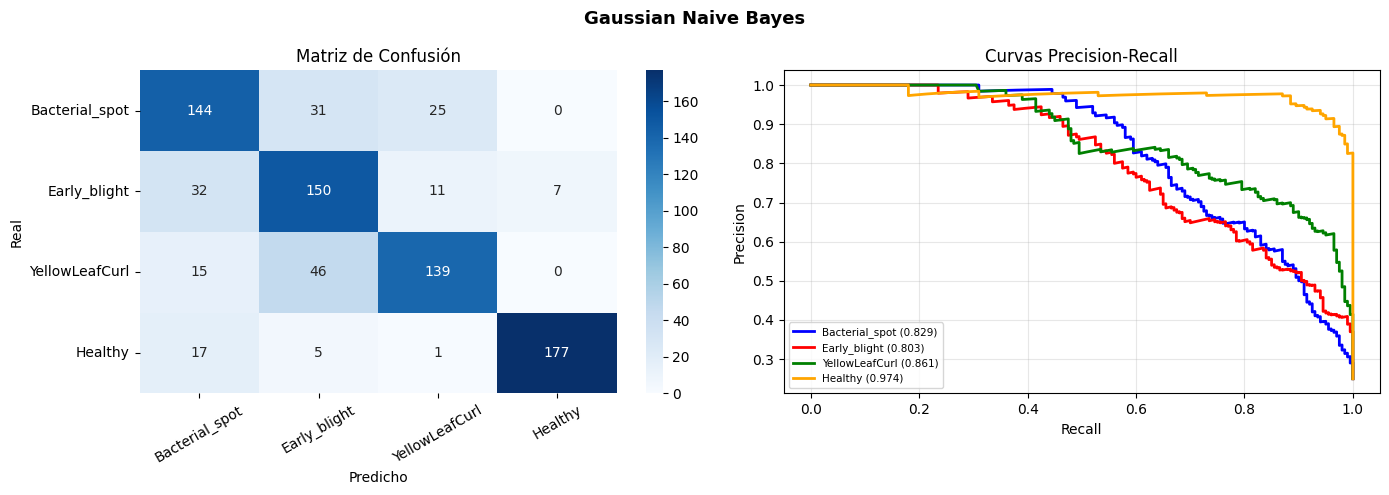


  Clase                AP
  ─────────────────────────
  Bacterial_spot   0.8293
  Early_blight     0.8033
  YellowLeafCurl   0.8607
  Healthy          0.9737



In [14]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
resultados_gnb = evaluar_modelo_completo(
    gnb_model, X_train, X_test, y_train, y_test,
    nombre_modelo="Gaussian Naive Bayes"
)

## DT


  Decision Tree (max_depth=5)
  Accuracy       : 0.8575  |  Precision (macro): 0.8612
  Recall (macro) : 0.8575  |  F1-Macro        : 0.8587
  F1-Weighted    : 0.8587
────────────────────────────────────────────────────────────
                precision  recall  f1-score  support
Bacterial_spot      0.839    0.81     0.824      200
Early_blight        0.727    0.80     0.762      200
YellowLeafCurl      0.878    0.83     0.853      200
Healthy             1.000    0.99     0.995      200
····························································
              precision  recall  f1-score  support
macro avg         0.861   0.857     0.859      800
weighted avg      0.861   0.858     0.859      800
────────────────────────────────────────────────────────────


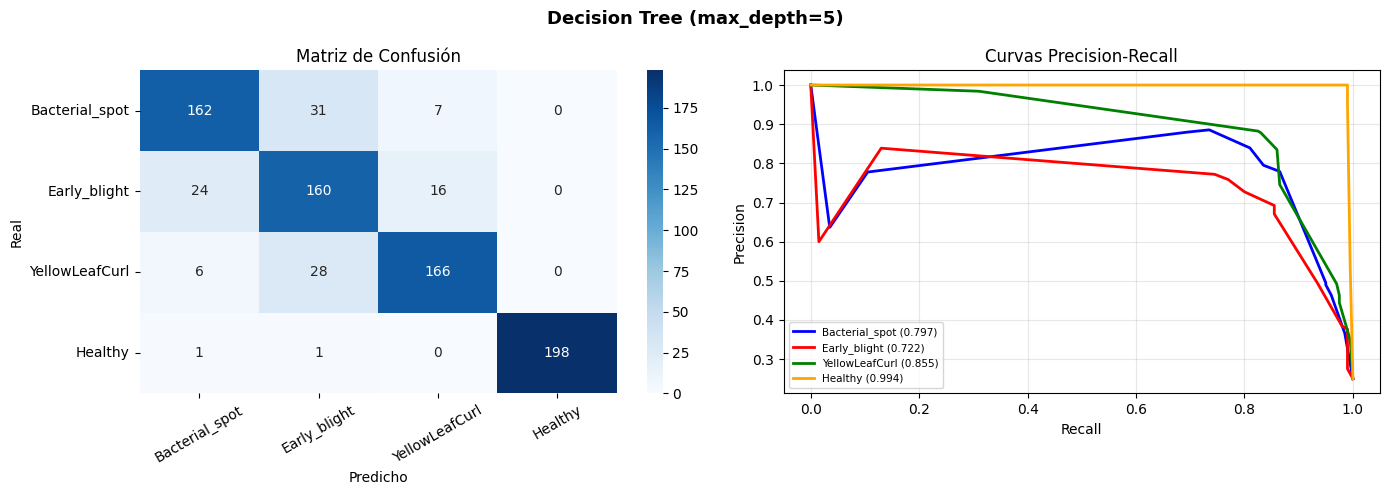


  Clase                AP
  ─────────────────────────
  Bacterial_spot   0.7971
  Early_blight     0.7221
  YellowLeafCurl   0.8549
  Healthy          0.9939



In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
resultados_dt = evaluar_modelo_completo(dt_model, X_train, X_test, y_train, y_test,
                                         nombre_modelo="Decision Tree (max_depth=5)")

## Random forest classifier


  Random Forest (150 árboles)
  Accuracy       : 0.9300  |  Precision (macro): 0.9298
  Recall (macro) : 0.9300  |  F1-Macro        : 0.9299
  F1-Weighted    : 0.9299
────────────────────────────────────────────────────────────
                precision  recall  f1-score  support
Bacterial_spot      0.893   0.880     0.887      200
Early_blight        0.881   0.885     0.883      200
YellowLeafCurl      0.950   0.955     0.953      200
Healthy             0.995   1.000     0.998      200
····························································
              precision  recall  f1-score  support
macro avg          0.93    0.93      0.93      800
weighted avg       0.93    0.93      0.93      800
────────────────────────────────────────────────────────────


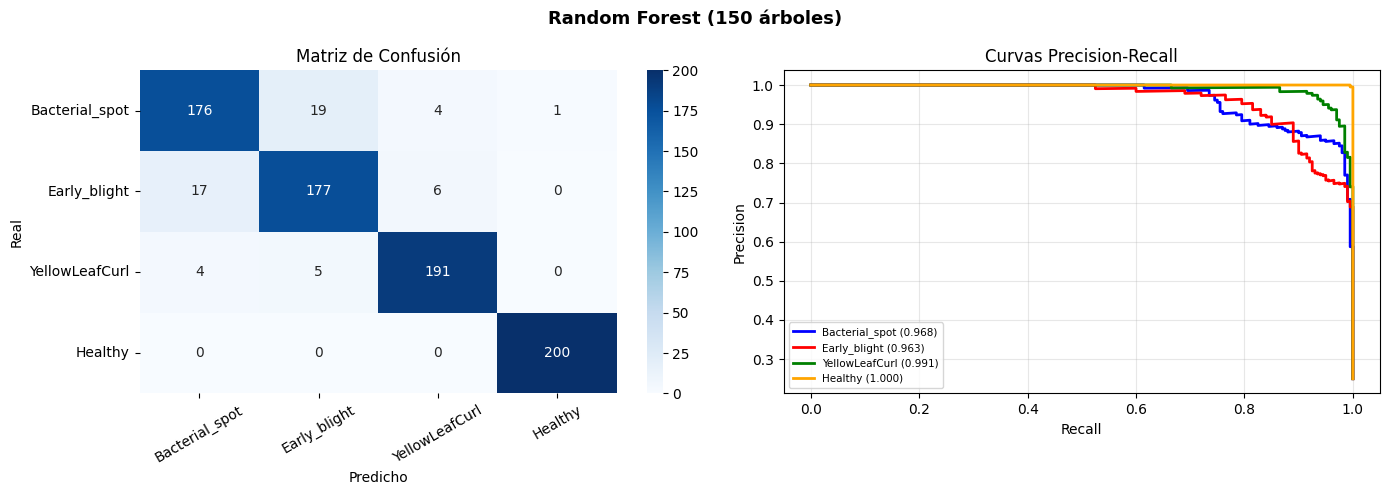


  Clase                AP
  ─────────────────────────
  Bacterial_spot   0.9677
  Early_blight     0.9631
  YellowLeafCurl   0.9910
  Healthy          1.0000



In [16]:
#@title **code:** working with a Random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=150,      # número de árboles
    max_depth=10,          # profundidad máxima (None = sin límite)
    min_samples_split=5,   # mínimo para dividir un nodo
    random_state=42,
    n_jobs=-1              # usa todos los cores
)
resultados_rf = evaluar_modelo_completo(
    rf_model, X_train, X_test, y_train, y_test,
    nombre_modelo="Random Forest (150 árboles)"
)

## SVM classification


  SVM (RBF kernel, C=10)
  Accuracy       : 0.9800  |  Precision (macro): 0.9801
  Recall (macro) : 0.9800  |  F1-Macro        : 0.9800
  F1-Weighted    : 0.9800
────────────────────────────────────────────────────────────
                precision  recall  f1-score  support
Bacterial_spot      0.961   0.975     0.968      200
Early_blight        0.965   0.965     0.965      200
YellowLeafCurl      0.995   0.980     0.987      200
Healthy             1.000   1.000     1.000      200
····························································
              precision  recall  f1-score  support
macro avg          0.98    0.98      0.98      800
weighted avg       0.98    0.98      0.98      800
────────────────────────────────────────────────────────────


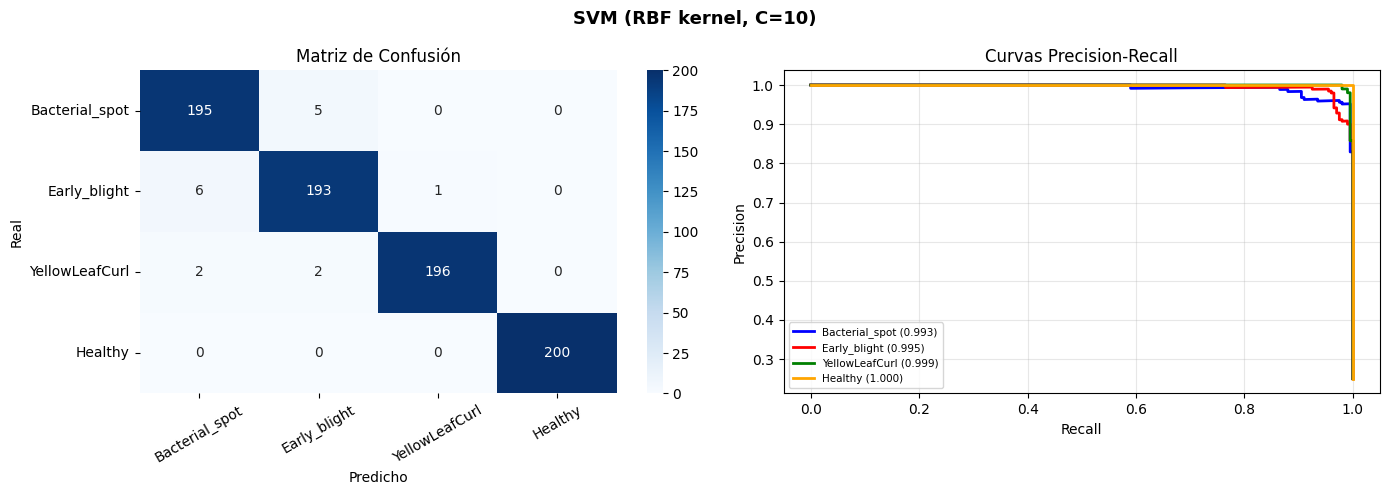


  Clase                AP
  ─────────────────────────
  Bacterial_spot   0.9931
  Early_blight     0.9953
  YellowLeafCurl   0.9991
  Healthy          1.0000



In [17]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(
    kernel='rbf',          # kernel radial (no lineal)
    C=10,                  # regularización (prueba 1, 10, 100)
    gamma='scale',         # parámetro del kernel
    probability=True,      # OBLIGATORIO para predict_proba
    random_state=42
)

resultados_svm = evaluar_modelo_completo(
    svm_model, X_train_scaled, X_test_scaled, y_train, y_test,
    nombre_modelo="SVM (RBF kernel, C=10)"
)

## Cross validation

In [18]:
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

def comparar_modelos_con_cv(modelos_dict, X_train, y_train, cv=5):
    """
    Compara modelos usando K-Fold Cross-Validation estratificado
    """
    print("=" * 80)
    print("COMPARACIÓN DE MODELOS CON 5-FOLD CROSS-VALIDATION")
    print("=" * 80)
    print(f"\n{'Modelo':<30} {'Accuracy':<20} {'F1-Macro':<20} {'Recall':<20} {'Fit Time (s)'}")
    print("-" * 80)

    resultados_cv = {}

    for nombre, modelo in modelos_dict.items():
        # Cross-validation con múltiples métricas
        cv_results = cross_validate(
            modelo, X_train, y_train,
            cv=cv,
            scoring=['accuracy', 'f1_macro', 'recall_macro'],
            return_train_score=True,
            n_jobs=-1
        )

        # Calcular promedios y desviaciones
        acc_mean = cv_results['test_accuracy'].mean()
        acc_std = cv_results['test_accuracy'].std()
        f1_mean = cv_results['test_f1_macro'].mean()
        f1_std = cv_results['test_f1_macro'].std()
        time_mean = cv_results['fit_time'].mean()
        rec_mean = cv_results['test_recall_macro'].mean()
        rec_std  = cv_results['test_recall_macro'].std()

        # Guardar resultados
        resultados_cv[nombre] = {
            'accuracy_mean': acc_mean,
            'accuracy_std': acc_std,
            'f1_mean': f1_mean,
            'f1_std': f1_std,
            'fit_time': time_mean,
            'cv_results': cv_results,
            'recall_mean': rec_mean,
            'recall_std':  rec_std,
        }

        # Imprimir
        print(f"{nombre:<30} {acc_mean:.4f} ± {acc_std:.4f}   {f1_mean:.4f} ± {f1_std:.4f}   {rec_mean:.4f} ± {rec_std:.4f}   {time_mean:.3f}")

    print("=" * 80)

    # Identificar el mejor modelo
    mejor_modelo = max(resultados_cv.items(), key=lambda x: x[1]['f1_mean'])
    print(f"\n🏆 MEJOR MODELO: {mejor_modelo[0]}")
    print(f"   F1-Macro: {mejor_modelo[1]['f1_mean']:.4f} ± {mejor_modelo[1]['f1_std']:.4f}")
    print(f"   Accuracy: {mejor_modelo[1]['accuracy_mean']:.4f} ± {mejor_modelo[1]['accuracy_std']:.4f}")
    return resultados_cv


# =============================================================================
# DEFINIR LOS 4 MODELOS
# =============================================================================

modelos = {
    "Gaussian NB": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),

    # SVM con Pipeline (incluye scaling automático)
    "SVM (RBF)": Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            probability=True,
            random_state=42
        ))
    ])
}

# =============================================================================
# EJECUTAR COMPARACIÓN CON CV
# =============================================================================

resultados_cv = comparar_modelos_con_cv(modelos, X_train, y_train, cv=5)

COMPARACIÓN DE MODELOS CON 5-FOLD CROSS-VALIDATION

Modelo                         Accuracy             F1-Macro             Recall               Fit Time (s)
--------------------------------------------------------------------------------
Gaussian NB                    0.7609 ± 0.0149   0.7626 ± 0.0146   0.7609 ± 0.0149   0.010
Decision Tree                  0.8759 ± 0.0164   0.8769 ± 0.0157   0.8759 ± 0.0164   0.095
Random Forest                  0.9362 ± 0.0046   0.9365 ± 0.0044   0.9362 ± 0.0046   2.996
SVM (RBF)                      0.9731 ± 0.0055   0.9731 ± 0.0056   0.9731 ± 0.0055   1.143

🏆 MEJOR MODELO: SVM (RBF)
   F1-Macro: 0.9731 ± 0.0056
   Accuracy: 0.9731 ± 0.0055


# Seleccion de caracterisitcas


=== K óptimo para SVC rbf: 28 / 29 features ===


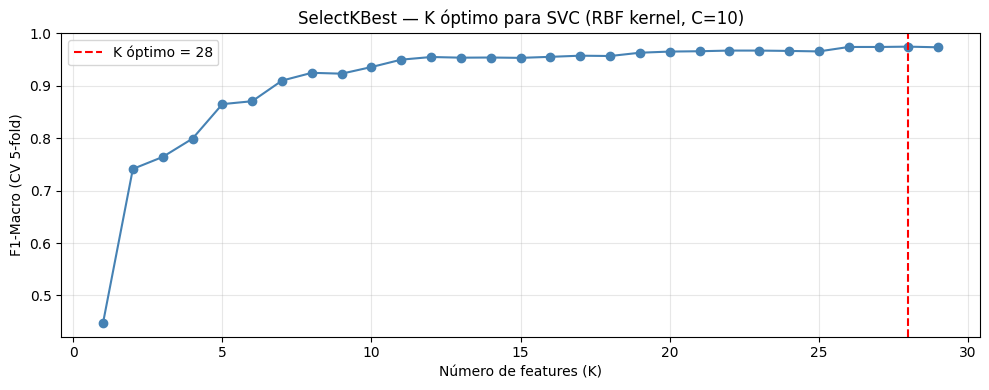


=== Scores de todas las features ===
    feature     score  p_value  seleccionada
  std_B_lab 1050.4928      0.0          True
      std_H  924.6625      0.0          True
     mean_S  794.1430      0.0          True
        ExG  749.1651      0.0          True
     mean_A  623.1151      0.0          True
     skew_B  510.0903      0.0          True
      std_A  494.9991      0.0          True
 mean_B_lab  470.9077      0.0          True
     mean_B  449.0303      0.0          True
   contrast  368.6100      0.0          True
     skew_R  365.8579      0.0          True
      std_G  356.5511      0.0          True
      std_V  352.4445      0.0          True
      std_L  339.3573      0.0          True
      var_G  328.6689      0.0          True
      std_R  326.1678      0.0          True
      std_S  305.0450      0.0          True
      var_R  297.5967      0.0          True
      var_B  247.2900      0.0          True
      std_B  236.7800      0.0          True
     mean_H  233.

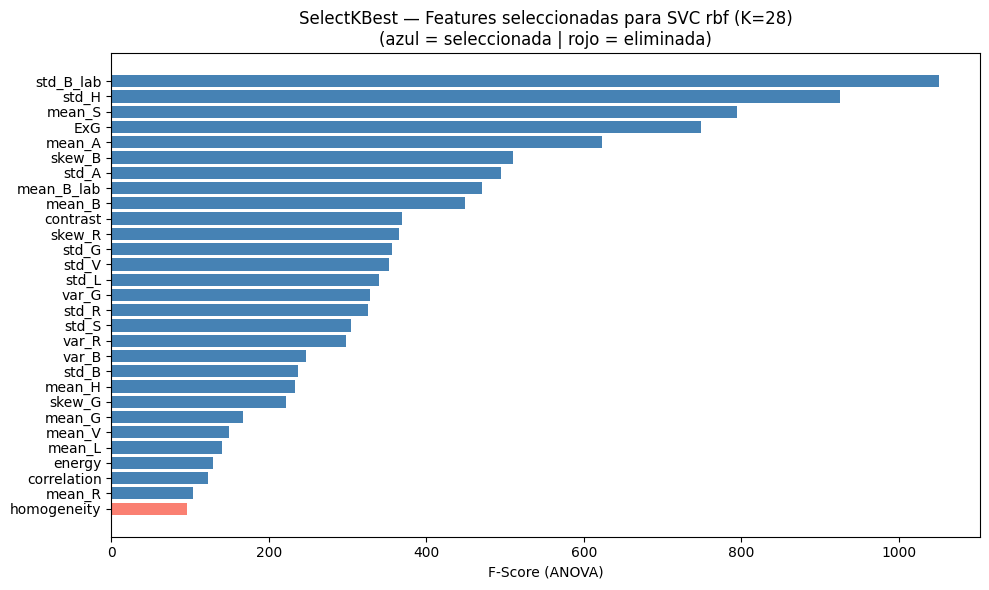

In [19]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

# ── 1. Buscar K óptimo usando el SVC rbf real ──────────────────────────────────
resultados_k = []
for k in range(1, X_train.shape[1] + 1):
    sel   = SelectKBest(f_classif, k=k)
    X_sel = sel.fit_transform(X_tr_sc, y_train)
    cv    = cross_val_score(
                SVC(kernel='rbf', C=10, gamma='scale', probability=False),
                X_sel, y_train, cv=5, scoring='f1_macro'
            )
    resultados_k.append({'k': k, 'f1_macro_cv': cv.mean()})

df_k     = pd.DataFrame(resultados_k)
k_optimo = int(df_k.loc[df_k['f1_macro_cv'].idxmax(), 'k'])
print(f"=== K óptimo para SVC rbf: {k_optimo} / {X_train.shape[1]} features ===")

# ── 2. Gráfica K vs F1 ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_k['k'], df_k['f1_macro_cv'], marker='o', color='steelblue')
ax.axvline(x=k_optimo, color='red', linestyle='--', label=f'K óptimo = {k_optimo}')
ax.set_xlabel('Número de features (K)')
ax.set_ylabel('F1-Macro (CV 5-fold)')
ax.set_title('SelectKBest — K óptimo para SVC (RBF kernel, C=10)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 3. Ajustar selector final y mostrar features ───────────────────────────────
selector_final = SelectKBest(f_classif, k=k_optimo)
selector_final.fit(X_tr_sc, y_train)

scores_df = pd.DataFrame({
    'feature':      X_train.columns,
    'score':        selector_final.scores_,
    'p_value':      selector_final.pvalues_,
    'seleccionada': selector_final.get_support()
}).sort_values('score', ascending=False).reset_index(drop=True)

print("\n=== Scores de todas las features ===")
print(scores_df.round(4).to_string(index=False))

features_sel = X_train.columns[selector_final.get_support()].tolist()
features_eli = X_train.columns[~selector_final.get_support()].tolist()
print(f"\n✅ SELECCIONADAS ({len(features_sel)}): {features_sel}")
print(f"❌ ELIMINADAS    ({len(features_eli)}): {features_eli}")

# ── 4. Gráfica de scores ───────────────────────────────────────────────────────
scores_plot = scores_df.sort_values('score')
colors      = ['steelblue' if s else 'salmon' for s in scores_plot['seleccionada']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(scores_plot['feature'], scores_plot['score'], color=colors)
ax.set_xlabel('F-Score (ANOVA)')
ax.set_title(f'SelectKBest — Features seleccionadas para SVC rbf (K={k_optimo})\n'
             '(azul = seleccionada | rojo = eliminada)')
plt.tight_layout()
plt.show()



## Recorte manual de 12 CARACTERISTICAS


=== Scores de todas las features ===
    feature     score  p_value  seleccionada
  std_B_lab 1050.4928      0.0          True
      std_H  924.6625      0.0          True
     mean_S  794.1430      0.0          True
        ExG  749.1651      0.0          True
     mean_A  623.1151      0.0          True
     skew_B  510.0903      0.0          True
      std_A  494.9991      0.0          True
 mean_B_lab  470.9077      0.0          True
     mean_B  449.0303      0.0          True
   contrast  368.6100      0.0          True
     skew_R  365.8579      0.0          True
      std_G  356.5511      0.0         False
      std_V  352.4445      0.0         False
      std_L  339.3573      0.0         False
      var_G  328.6689      0.0         False
      std_R  326.1678      0.0         False
      std_S  305.0450      0.0         False
      var_R  297.5967      0.0         False
      var_B  247.2900      0.0         False
      std_B  236.7800      0.0         False
     mean_H  233.

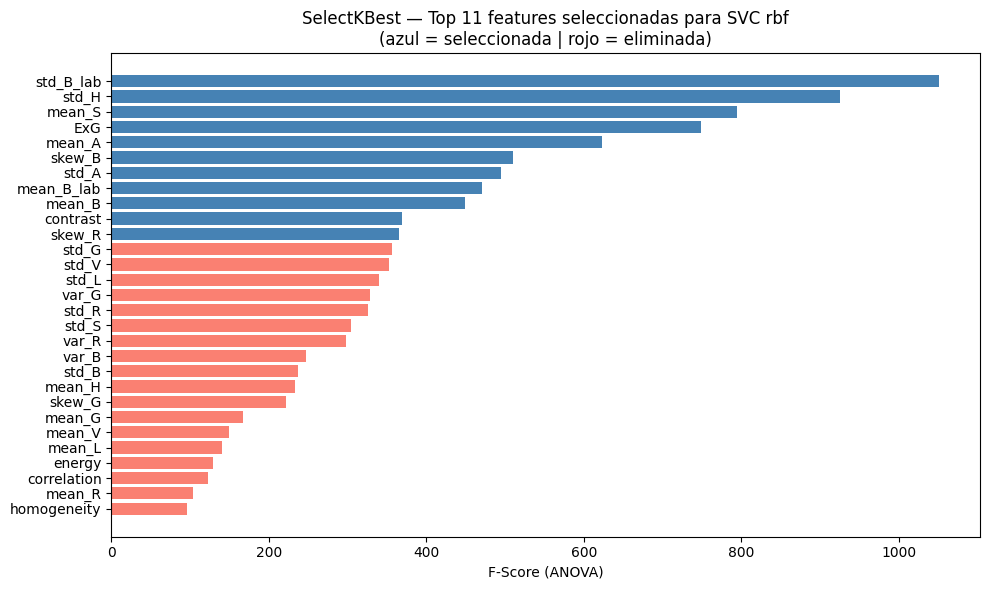


  SVM (RBF, C=10) — 11 features (SelectKBest)
  Accuracy       : 0.9563  |  Precision (macro): 0.9565
  Recall (macro) : 0.9563  |  F1-Macro        : 0.9563
  F1-Weighted    : 0.9563
────────────────────────────────────────────────────────────
                precision  recall  f1-score  support
Bacterial_spot      0.939   0.920     0.929      200
Early_blight        0.912   0.935     0.923      200
YellowLeafCurl      0.975   0.970     0.972      200
Healthy             1.000   1.000     1.000      200
····························································
              precision  recall  f1-score  support
macro avg         0.956   0.956     0.956      800
weighted avg      0.956   0.956     0.956      800
────────────────────────────────────────────────────────────


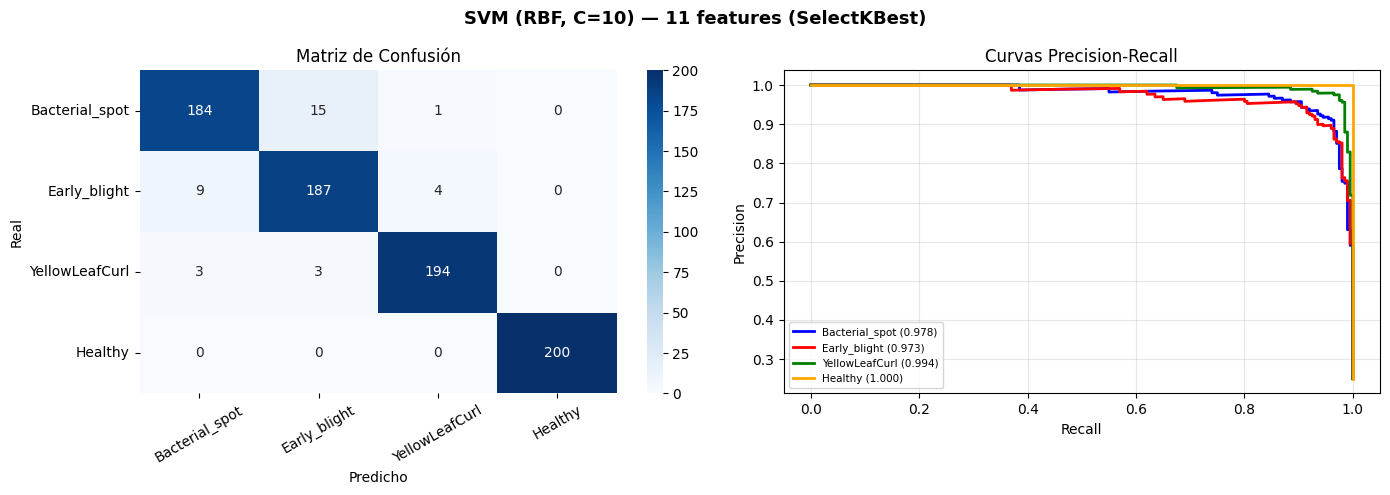


  Clase                AP
  ─────────────────────────
  Bacterial_spot   0.9775
  Early_blight     0.9725
  YellowLeafCurl   0.9939
  Healthy          1.0000



In [29]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

# ── 1. Ajustar selector con K=12 fijo ─────────────────────────────────────────
k_optimo = 11

selector_final = SelectKBest(f_classif, k=k_optimo)
selector_final.fit(X_tr_sc, y_train)

scores_df = pd.DataFrame({
    'feature':      X_train.columns,
    'score':        selector_final.scores_,
    'p_value':      selector_final.pvalues_,
    'seleccionada': selector_final.get_support()
}).sort_values('score', ascending=False).reset_index(drop=True)

print("\n=== Scores de todas las features ===")
print(scores_df.round(4).to_string(index=False))

features_sel = X_train.columns[selector_final.get_support()].tolist()
features_eli = X_train.columns[~selector_final.get_support()].tolist()
print(f"\n✅ SELECCIONADAS ({len(features_sel)}): {features_sel}")
print(f"❌ ELIMINADAS    ({len(features_eli)}): {features_eli}")

# ── 2. Gráfica de scores ───────────────────────────────────────────────────────
scores_plot = scores_df.sort_values('score')
colors      = ['steelblue' if s else 'salmon' for s in scores_plot['seleccionada']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(scores_plot['feature'], scores_plot['score'], color=colors)
ax.set_xlabel('F-Score (ANOVA)')
ax.set_title(f'SelectKBest — Top {k_optimo} features seleccionadas para SVC rbf\n'
             '(azul = seleccionada | rojo = eliminada)')
plt.tight_layout()
plt.show()

# ── 3. Transformar ────────────────────────────────────────────────────────────
X_train_sel = selector_final.transform(X_tr_sc)
X_test_sel  = selector_final.transform(X_te_sc)

# ── 4. Evaluar ────────────────────────────────────────────────────────────────
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

resultados_svm = evaluar_modelo_completo(
    svm_model, X_train_sel, X_test_sel, y_train, y_test,
    nombre_modelo=f"SVM (RBF, C=10) — {k_optimo} features (SelectKBest)"
)

### Curvas de Aprendizaje para el SVM (RBF) con las características seleccionadas

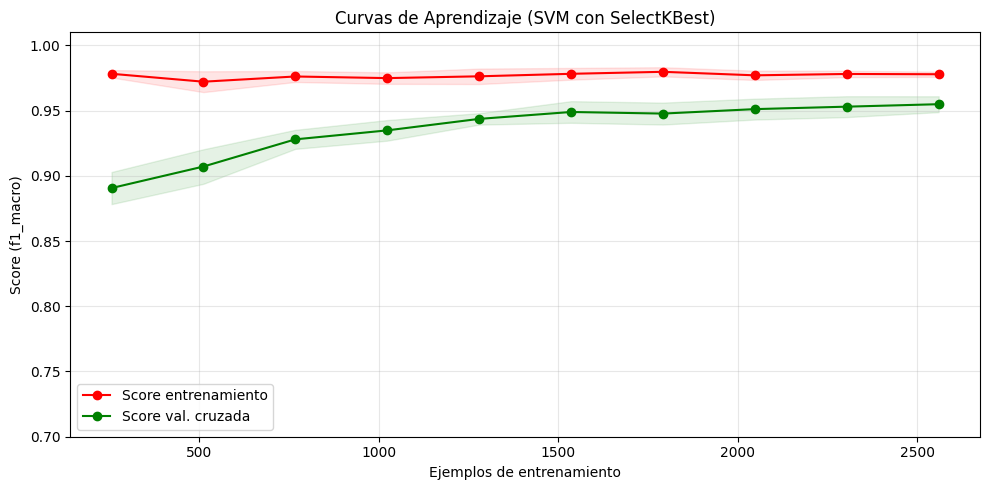

In [21]:
fig, axes = plt.subplots(1, 1, figsize=(10, 5)) # Cambiado a un solo plot

# Usamos el modelo SVC con los parámetros ya definidos
# No es necesario escalar X_train_sel porque ya está escalado
plot_learning_curve(
    svm_model, # Reutilizamos el svm_model ya instanciado
    "Curvas de Aprendizaje (SVM con SelectKBest)",
    X_train_sel, # Usamos las características seleccionadas
    y_train,
    axes=[axes], # Pasamos el único eje envuelto en una lista
    ylim=(0.7, 1.01),
    cv=5, # Usamos 5-fold cross-validation
    n_jobs=-1, # Usamos todos los núcleos disponibles
    scoring='f1_macro' # La métrica que nos interesa
)

plt.tight_layout()
plt.show()

### Curvas de Aprendizaje para Gaussian Naive Bayes

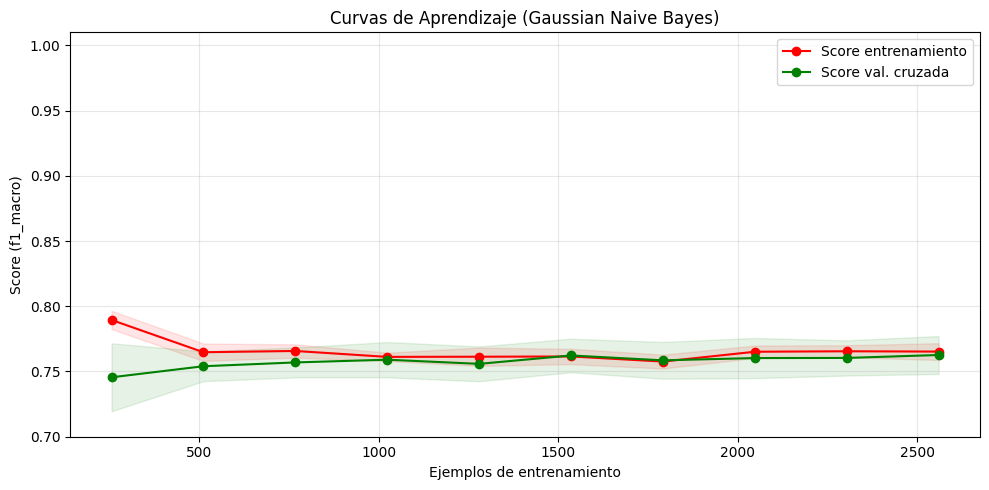

In [22]:
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

plot_learning_curve(
    gnb_model,
    "Curvas de Aprendizaje (Gaussian Naive Bayes)",
    X_train,
    y_train,
    axes=[axes],
    ylim=(0.7, 1.01),
    cv=5,
    n_jobs=-1,
    scoring='f1_macro'
)

plt.tight_layout()
plt.show()

### Curvas de Aprendizaje para Decision Tree

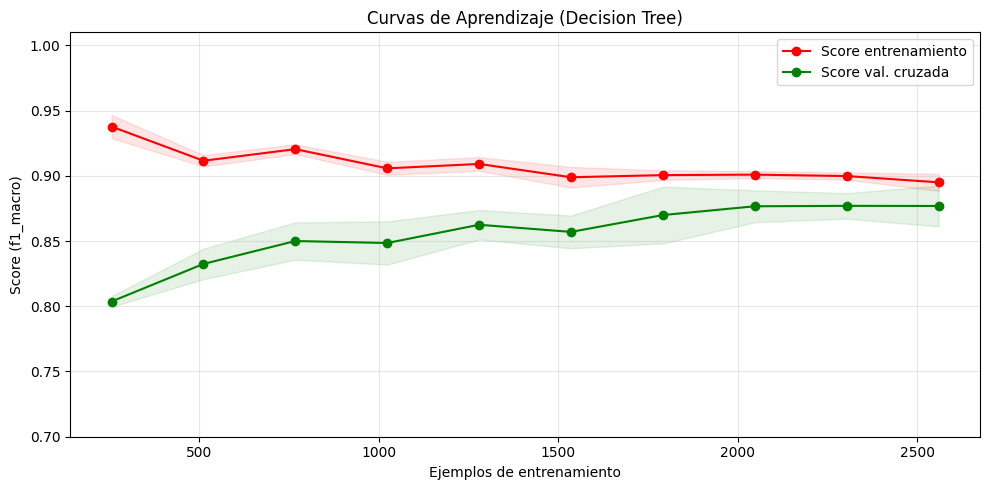

In [23]:
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

plot_learning_curve(
    dt_model,
    "Curvas de Aprendizaje (Decision Tree)",
    X_train,
    y_train,
    axes=[axes],
    ylim=(0.7, 1.01),
    cv=5,
    n_jobs=-1,
    scoring='f1_macro'
)

plt.tight_layout()
plt.show()

### Curvas de Aprendizaje para Random Forest

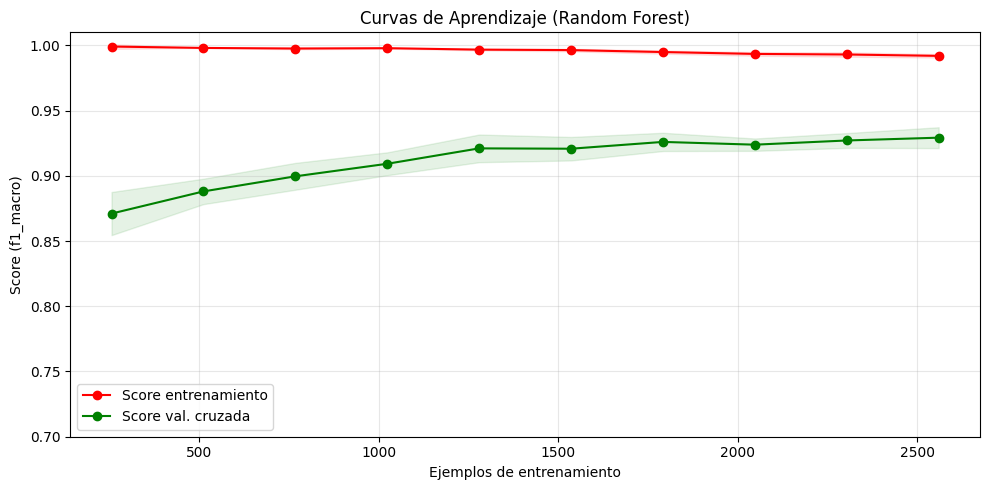

In [24]:
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

plot_learning_curve(
    rf_model,
    "Curvas de Aprendizaje (Random Forest)",
    X_train,
    y_train,
    axes=[axes],
    ylim=(0.7, 1.01),
    cv=5,
    n_jobs=-1,
    scoring='f1_macro'
)

plt.tight_layout()
plt.show()

### Curvas de Aprendizaje para el SVM (RBF) con todas las características escaladas

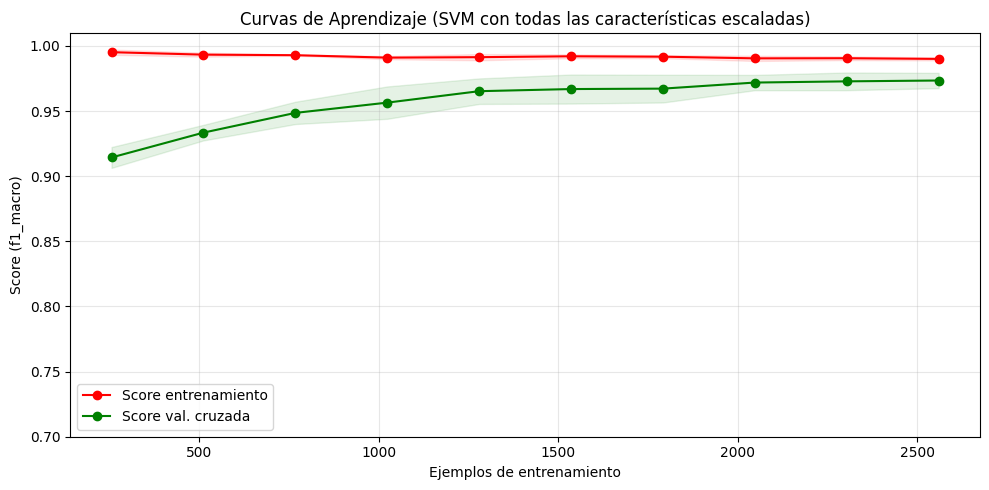

In [25]:
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# Reutilizamos el svm_model ya instanciado, pero usando X_train_scaled
plot_learning_curve(
    svm_model,
    "Curvas de Aprendizaje (SVM con todas las características escaladas)",
    X_train_scaled, # Usamos las características escaladas completas
    y_train,
    axes=[axes],
    ylim=(0.7, 1.01),
    cv=5,
    n_jobs=-1,
    scoring='f1_macro'
)

plt.tight_layout()
plt.show()

### Curvas de Aprendizaje para la Red Neuronal (DNN)

# DEEP LEARNING

Model: "DNN_Tomato"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,628 (64.95 KB)

 Trainable params: 16,628 (64.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6428 - loss: 0.8462 - val_accuracy: 0.8338 - val_loss: 0.4370 - learning_rate: 0.0010
Epoch 2/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8587 - loss: 0.4100 - val_accuracy: 0.9013 - val_loss: 0.2930 - learning_rate: 0.0010
Epoch 3/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8866 - loss: 0.3265 - val_accuracy: 0.9162 - val_loss: 0.2388 - learning_rate: 0.0010
Epoch 4/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9034 - loss: 0.2821 - val_accuracy: 0.9187 - val_loss: 0.2143 - learning_rate: 0.0010
Epoch 5/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9091 - loss: 0.2459 - val_accuracy: 0.9250 - val_loss: 0.1882 - learning_rate: 0.0010
Epoch 6/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9253 - loss: 0.2228 - val_accuracy: 0.9175 - val_loss: 0.1884 - learning_rate: 0.0010
Epoch 7/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9244 - loss: 0.2089 -

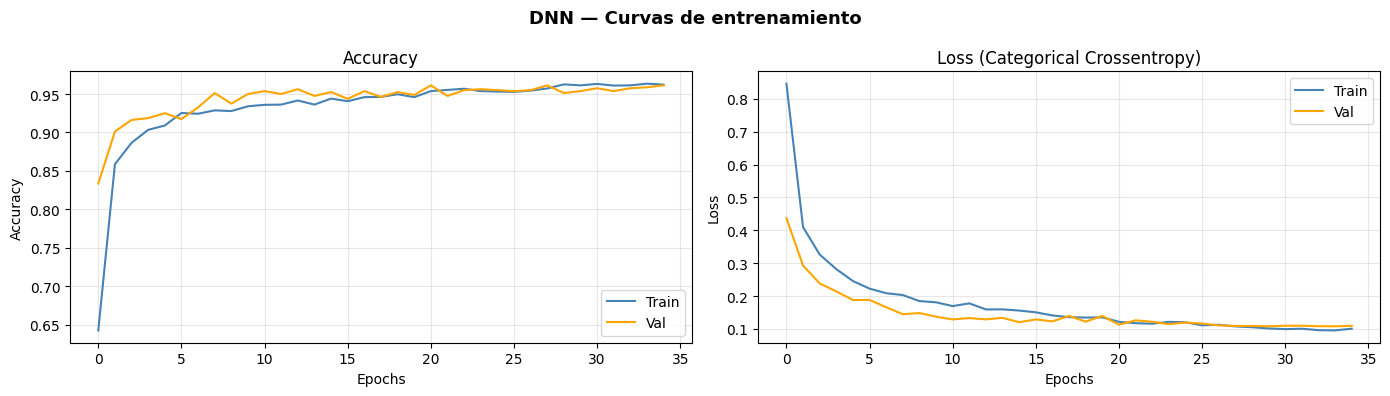


  DNN (11 features, SelectKBest)
  Accuracy       : 0.9587  |  Precision (macro): 0.9592
  Recall (macro) : 0.9587  |  F1-Macro        : 0.9589
  F1-Weighted    : 0.9589
────────────────────────────────────────────────────────────
                precision  recall  f1-score  support
Bacterial_spot      0.944   0.935     0.940      200
Early_blight        0.913   0.945     0.929      200
YellowLeafCurl      0.979   0.955     0.967      200
Healthy             1.000   1.000     1.000      200
····························································
              precision  recall  f1-score  support
macro avg         0.959   0.959     0.959      800
weighted avg      0.959   0.959     0.959      800
────────────────────────────────────────────────────────────


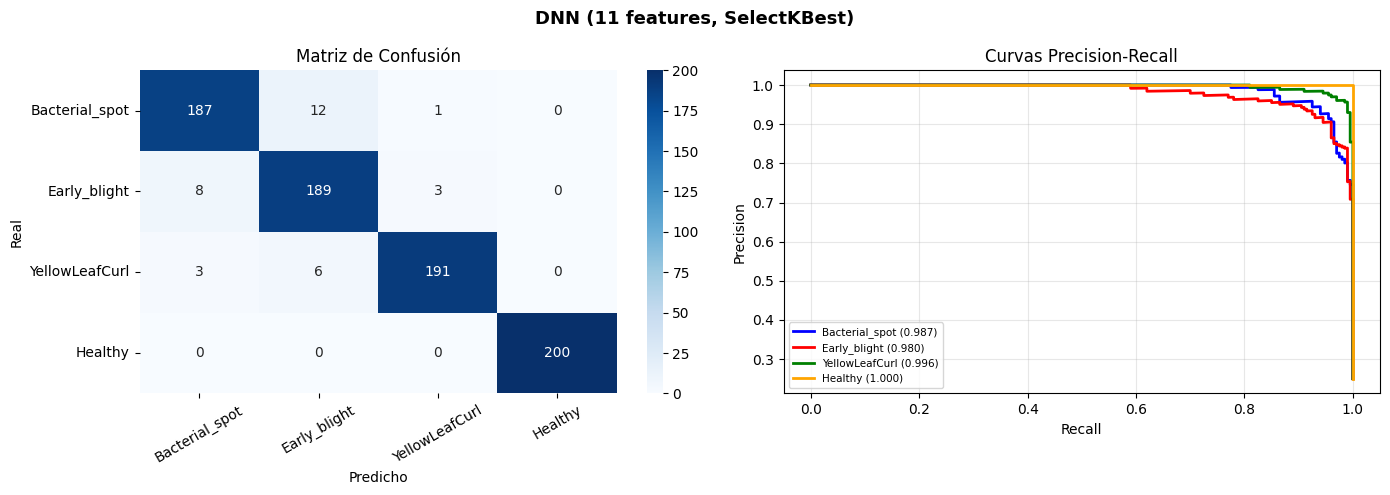


  Clase                AP
  ─────────────────────────
  Bacterial_spot   0.9867
  Early_blight     0.9798
  YellowLeafCurl   0.9961
  Healthy          1.0000



In [33]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
import numpy as np

# ── 1. One-Hot Encoding de las etiquetas ──────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
y_train_ohe = to_categorical(y_train_enc, num_classes=4)
y_test_ohe  = to_categorical(y_test_enc,  num_classes=4)

# ── 2. Arquitectura DNN ───────────────────────────────────────────────────────
model = tf.keras.Sequential([
    layers.Input(shape=(11,)),                                        # 11 features
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),                                              # evita sobreajuste
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(4, activation='softmax')                             # 4 clases
], name="DNN_Tomato")

model.summary()

# ── 3. Compilar ───────────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',                                  # multiclase
    metrics=['accuracy']
)

# ── 4. Callbacks ──────────────────────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True                                     # guarda el mejor epoch
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6                                       # baja lr si estanca
    )
]

# ── 5. Entrenar ───────────────────────────────────────────────────────────────
history = model.fit(
    X_train_sel, y_train_ohe,
    epochs=35,
    batch_size=32,
    validation_data=(X_test_sel, y_test_ohe),
    callbacks=callbacks,
    verbose=1
)

# ── 6. Gráficas de entrenamiento ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('DNN — Curvas de entrenamiento', fontsize=13, weight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   color='orange')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss (Categorical Crossentropy)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── 7. Evaluar con evaluar_modelo_completo ────────────────────────────────────
# Wrapper para que sea compatible con sklearn (necesita .predict y .predict_proba)
class KerasWrapper:
    def __init__(self, keras_model, label_encoder):
        self.model_        = keras_model
        self.le_           = label_encoder
        self.classes_      = label_encoder.classes_

    def fit(self, X, y):                                              # ya entrenado
        pass

    def predict(self, X):
        proba = self.model_.predict(X, verbose=0)
        return self.le_.inverse_transform(np.argmax(proba, axis=1))

    def predict_proba(self, X):
        return self.model_.predict(X, verbose=0)

dnn_wrapper = KerasWrapper(model, le)

resultados_dnn = evaluar_modelo_completo(
    dnn_wrapper, X_train_sel, X_test_sel, y_train, y_test,
    nombre_modelo="DNN (11 features, SelectKBest)"
)